# ❤️ Heart Disease Prediction using Machine Learning
#  Project Overview

This project focuses on predicting heart disease using Machine Learning algorithms. The objective is to analyze patient medical data and build predictive models capable of identifying whether a patient is likely to suffer from heart disease.

The project demonstrates the complete Machine Learning workflow including:

Data preprocessing

Feature engineering

Handling imbalanced datasets

Model training

Hyperparameter tuning

Model evaluation

Visualization of results

This project was implemented using Python and various machine learning libraries from the Scikit-learn ecosystem.

# 📂 Dataset Description

The dataset contains medical records of patients with different health-related attributes.

# Features Used
Age

Sex

Chest Pain Type

Resting Blood Pressure

Cholesterol

Fasting Blood Sugar

Resting ECG

Maximum Heart Rate

Exercise-Induced Angina

ST Depression

ST Slope

# Target Variable
0 → No Heart Disease

1 → Heart Disease Present

# 🛠 Technologies and Libraries Used
# Programming Language
Python

# Libraries
NumPy

Pandas

Matplotlib

Scikit-learn

Imbalanced-learn

Mlxtend

### 1.Importing Required Libraries
NumPy (numpy): Used for numerical computations, arrays, and mathematical operations.

Pandas (pandas): Used for data analysis, data manipulation, and handling datasets in table format.

In [171]:
import numpy as np # Used for numerical calculations and arrays
import pandas as pd  # Used for data analysis and handling datasets


### 2.Loading the Dataset
Reads the heart.csv dataset file using Pandas.

Stores the dataset in the variable data.

Displays the dataset in tabular format.

In [172]:
data = pd.read_csv('heart.csv')   # Reads the heart.csv dataset file

data   # Displays the dataset

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


### 3.Checking Data Types
Displays the datatype of each column in the dataset.

Helps identify numerical and categorical features.

In [173]:
data.dtypes   # Displays the datatype of each column in the dataset

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

### 4.Checking Missing Values

Checks for missing (null) values in each column

Displays the total number of missing values present in the dataset.

In [174]:
data.isnull().sum()   # Checks missing (null) values in each column

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### 5.Selecting Input Features
Selects columns from index 0 to 10 as input features.

Stores the independent variables in x.

In [175]:
x = data.iloc[:, 0:11]   # Selects columns from index 0 to 10 as input features

x

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up
...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat


### 6.Selecting Target Variable


Selects the HeartDisease column as the target/output variable.

Stores the dependent variable in y.

In [176]:
y = data['HeartDisease']   # Selects the target/output column

y

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64

### 7.Checking Unique Values in Age Column

Displays all unique values present in the Age column.

Helps understand the different age values in the dataset.

In [177]:
data.Age.unique()   # Displays unique values present in the Age column

array([40, 49, 37, 48, 54, 39, 45, 58, 42, 38, 43, 60, 36, 44, 53, 52, 51,
       56, 41, 32, 65, 35, 59, 50, 47, 31, 46, 57, 55, 63, 66, 34, 33, 61,
       29, 62, 28, 30, 74, 68, 72, 64, 69, 67, 73, 70, 77, 75, 76, 71],
      dtype=int64)

### 8.Checking Unique Values in 12th Column

Displays all unique values present in the 12th column of the dataset.

Helps identify the distinct categories or values in that column.

In [178]:
data.iloc[:,11].unique()   # Displays unique values from the 12th column

array([0, 1], dtype=int64)

### 9.Defining Column Categories

nomi_col → Stores indexes of nominal categorical columns.

ordi_col → Stores indexes of ordinal categorical columns.

num_col → Stores indexes of numerical columns.

Helps in applying appropriate preprocessing techniques to different data types.

In [179]:
nomi_col = [2, 6, 10]   # Nominal categorical column indexes

ordi_col = [1, 8]       # Ordinal categorical column indexes

num_col = [0, 3, 4, 5, 7, 9]   # Numerical column indexes

### 10.Data Preprocessing and Transformation
Imports preprocessing tools for encoding and scaling data.

OneHotEncoder → Converts nominal categorical data into binary format.

OrdinalEncoder → Converts ordinal categorical data into numerical order.

StandardScaler → Standardizes numerical features.

make_column_transformer → Applies different transformations to different columns.

set_config → Configures sklearn display settings.

In [180]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
# Imports encoders and scaler for data preprocessing

from sklearn.compose import make_column_transformer
# Used to apply different transformations to different columns

from sklearn import set_config
# Used to configure sklearn display settings


trans = make_column_transformer(

    (OneHotEncoder(sparse_output=False), nomi_col),
    # Applies One-Hot Encoding to nominal categorical columns

    (OrdinalEncoder(), ordi_col),
    # Applies Ordinal Encoding to ordinal categorical columns

    (StandardScaler(), num_col),
    # Standardizes numerical columns

    remainder='passthrough'
    # Keeps remaining columns unchanged
)

set_config(display='diagram')
# Displays transformer structure in diagram format

trans
# Shows the created column transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(sparse_output=False),
                                 [2, 6, 10]),
                                ('ordinalencoder', OrdinalEncoder(), [1, 8]),
                                ('standardscaler', StandardScaler(),
                                 [0, 3, 4, 5, 7, 9])])

### 11.Splitting the Dataset
Imports train_test_split to divide the dataset into training and testing sets.

### Splits the data into:
x_train, y_train → Training data

x_test, y_test → Testing data

test_size=0.2 means 20% of the data is used for testing and 80% for training.

In [258]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size= 0.2)

### 12.Creating the Machine Learning Pipeline
Imports the KNeighborsClassifier algorithm.

Imports make_pipeline to create a preprocessing and modeling pipeline.

In [182]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
Model= KNeighborsClassifier(10)
pipe = make_pipeline(trans, Model)

### 13.Displaying the Model
Displays the created K-Nearest Neighbors (KNN) classification model.

Shows the model parameters and configuration.

In [183]:
Model

KNeighborsClassifier(n_neighbors=10)

### 14.Displaying the Pipeline
Displays the complete machine learning pipeline.

Shows both the preprocessing steps and the KNN model combined together.

In [184]:
pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=10))])

### 15.Training the Model
Trains the machine learning pipeline using the training data.

Applies preprocessing steps and fits the KNN model to the dataset.

In [185]:
pipe.fit(x_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=10))])

### 16.Making Predictions
Uses the trained pipeline to make predictions on the test data.

Stores the predicted output values in pred.

In [257]:
pred=pipe.predict (x_test)

### 17.Displaying Predicted Values
Displays the predicted results generated by the trained model.

Shows the output values predicted for the test dataset.

In [187]:
pred

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0], dtype=int64)

### 18.Calculating Model Accuracy
Imports accuracy_score to evaluate model performance.

Compares predicted values with actual test values.

Calculates the accuracy percentage of the model.

In [188]:
from sklearn.metrics import accuracy_score
accuracy_score(pred, y_test)*100

85.32608695652173

### 19.Creating KNN Classification Pipeline
Imports the K-Nearest Neighbors (KNN) classifier.

Imports make_pipeline to combine preprocessing and model training steps.

In [189]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
perceptronalg= KNeighborsClassifier(10)
pipe = make_pipeline(trans, perceptronalg)

### 20.Creating Perceptron Classification Pipeline
Imports the Perceptron classification algorithm.

Imports make_pipeline to combine preprocessing and model training steps.

In [190]:
from sklearn.linear_model import Perceptron
from sklearn.pipeline import make_pipeline
prc = Perceptron(class_weight='balanced')
#perceptronalg= KNeighborsClassifier(2)
pipe_prc = make_pipeline(trans,prc)
pipe_prc


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('perceptron', Perceptron(class_weight='balanced'))])

### 21.Training the Perceptron Model
Trains the Perceptron pipeline using the training dataset.

Applies preprocessing steps and fits the Perceptron model to the data.

In [191]:
pipe_prc.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('perceptron', Perceptron(class_weight='balanced'))])

### 22.Making Predictions with Perceptron Model
Uses the trained Perceptron pipeline to predict values for the test dataset.

Stores the predicted results in pred_prc.

In [192]:
pred_prc= pipe_prc.predict(x_test)

### 23.Calculating Perceptron Model Accuracy
Compares the predicted values with the actual test values.

Calculates the accuracy percentage of the Perceptron model.

Helps evaluate the model’s prediction performance.

In [193]:
accuracy_score(pred_prc, y_test)*100

82.6086956521739

### 24.Training Perceptron Model with Selected Features
Selects MaxHR and Age as input features.

Selects HeartDisease as the target variable.

In [194]:
x2=data.loc[:,['MaxHR','Age']]
y2=data.HeartDisease
#Model= KNeighborsClassifier(10)
prc = Perceptron(class_weight='balanced')

prc.fit(x2,y2)

Perceptron(class_weight='balanced')

### 25.Visualizing Decision Regions
Imports plot_decision_regions for visualizing classification boundaries.

Plots the decision regions created by the Perceptron model.

Uses MaxHR and Age features to visualize how the model separates classes.

legend=2 displays class labels in the plot.

C:\Users\gowth\ANACONDA\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

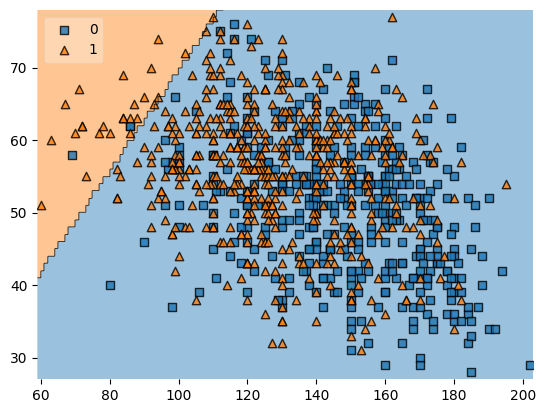

In [259]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x2.values,y2.values,clf=prc,legend=2)

### 26.Creating Logistic Regression Pipeline
Imports the LogisticRegression classification algorithm.

Imports make_pipeline to combine preprocessing and model training.

model = LogisticRegression(solver='liblinear')

Creates a Logistic Regression model using the liblinear solver.

#### Builds a pipeline that:
Applies preprocessing using trans

Trains the Logistic Regression model

Displays the complete pipeline structure.

In [196]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
model= LogisticRegression (solver='liblinear')
pipe= make_pipeline(trans,model)
pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('logisticregression', LogisticRegression(solver='liblinear'))])

### 27.Training the Logistic Regression Model
Trains the Logistic Regression pipeline using the training dataset.

Applies preprocessing steps and fits the model to the training data.

In [197]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('logisticregression', LogisticRegression(solver='liblinear'))])

### 28.Making Predictions with Logistic Regression
Uses the trained Logistic Regression pipeline to predict values for the test dataset.

Stores the predicted results in the variable prediction.

In [198]:
prediction = pipe.predict(x_test)

### 29.Displaying Predicted Results
Displays the predicted output values generated by the Logistic Regression model.

Shows the model’s predictions for the test dataset.

In [199]:
prediction

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0], dtype=int64)

### 30.Calculating Logistic Regression Accuracy
Compares the predicted values with the actual test values.

Calculates the accuracy percentage of the Logistic Regression model.

Helps evaluate the model’s overall performance.

In [200]:
accuracy_score(prediction,y_test)*100

85.32608695652173

### 31.Creating Support Vector Machine (SVM) Pipeline
Imports the SVC (Support Vector Classifier) algorithm.

Imports make_pipeline to combine preprocessing and model training.

algorithm = SVC()

pipe3 = make_pipeline(trans, algorithm)

pipe3
Creates a Support Vector Machine (SVM) classification model.

#### Builds a pipeline that:
Applies preprocessing using trans

Trains the SVM model

Displays the complete pipeline structure.

In [201]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
algorithm=SVC()
pipe3= make_pipeline(trans,algorithm)
pipe3

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('svc', SVC())])

### 32.Training the SVM Model
Trains the Support Vector Machine (SVM) pipeline using the training dataset.

Applies preprocessing steps and fits the SVM model to the data.

In [202]:
pipe3.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('svc', SVC())])

### 33.Making Predictions with SVM Model
Uses the trained SVM pipeline to predict values for the test dataset.

Stores the predicted results in the variable prediction3.

In [203]:
prediction3=pipe3.predict(x_test)

### 34.Calculating SVM Model Accuracy
Compares the predicted values with the actual test values.

Calculates the accuracy percentage of the Support Vector Machine (SVM) model.

Helps evaluate the model’s prediction performance.

In [204]:
accuracy_score(prediction3,y_test)*100

84.78260869565217

### 35.Visualizing Target Variable Distribution
Imports the Seaborn library for data visualization.

Creates a count plot for the target variable y.

Displays the number of occurrences of each class in the dataset.

Helps identify class distribution and dataset balance.

<Axes: ylabel='count'>

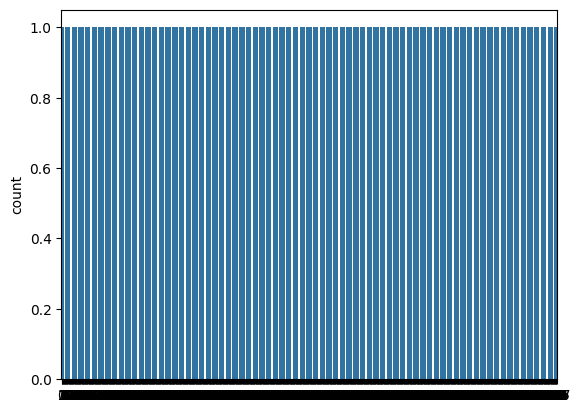

In [205]:
import seaborn as sns
sns.countplot(y)

### 36.Applying Random Under Sampling
Imports RandomUnderSampler to balance the dataset.

Reduces the number of samples from the majority class.

Creates balanced feature (u_x) and target (u_y) datasets.

Displays the count of samples in each class after under sampling.

In [206]:
from imblearn.under_sampling import RandomUnderSampler
under= RandomUnderSampler()
u_x,u_y = under.fit_resample(x,y)
u_y.value_counts()

HeartDisease
0    410
1    410
Name: count, dtype: int64

### 37.Applying Random Over Sampling
Imports RandomOverSampler to balance the dataset.

Increases the number of samples in the minority class.

Creates balanced feature (u_x) and target (u_y) datasets.

Displays the count of samples in each class after over sampling.

In [207]:
from imblearn.over_sampling import RandomOverSampler
under = RandomOverSampler()
u_x, u_y = under.fit_resample(x,y)
u_y.value_counts()

HeartDisease
0    508
1    508
Name: count, dtype: int64

### 38.Creating Pipeline with SMOTE and SVM
Imports sampling techniques and pipeline utilities from imblearn.

SMOTE is used to balance imbalanced datasets by generating synthetic samples.

s = SMOTE()

pipe4 = make_pipeline(trans, s, algorithm)

pipe4

Creates a SMOTE object for over-sampling the minority class.

#### Builds a pipeline that:
Applies preprocessing using trans

Balances the dataset using SMOTE

Trains the SVM model (algorithm)

Displays the complete pipeline structure.

In [208]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import make_pipeline
s = SMOTE()
pipe4 = make_pipeline(trans,s,algorithm)
pipe4

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('smote', SMOTE()), ('svc', SVC())])

### 39.Training the SMOTE + SVM Pipeline
Trains the machine learning pipeline using the training dataset.

Applies preprocessing, balances the data using SMOTE, and trains the SVM model.

In [209]:
pipe4.fit(x_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('smote', SMOTE()), ('svc', SVC())])

### 40.Making Predictions with SMOTE + SVM Pipeline
Uses the trained pipeline to predict values for the test dataset.

Applies preprocessing and the trained SVM model to generate predictions.

Displays the predicted output values.

In [210]:
prediction4 = pipe4.predict(x_test)
prediction4

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0], dtype=int64)

### 41.Calculating SMOTE + SVM Model Accuracy
Compares the predicted values with the actual test values.

Calculates the accuracy percentage of the SMOTE + SVM model.

Helps evaluate the performance of the balanced classification model.

In [211]:
accuracy_score(prediction4, y_test)*100

85.32608695652173

### 42.Plotting the Confusion Matrix
Imports ConfusionMatrixDisplay for visualizing model performance.

Imports matplotlib.pyplot for displaying plots.

Generates a confusion matrix using the trained pipe4 model.

Compares predicted values with actual test values.

cmap='Blues' applies a blue color theme to the plot.

Displays the confusion matrix visualization.

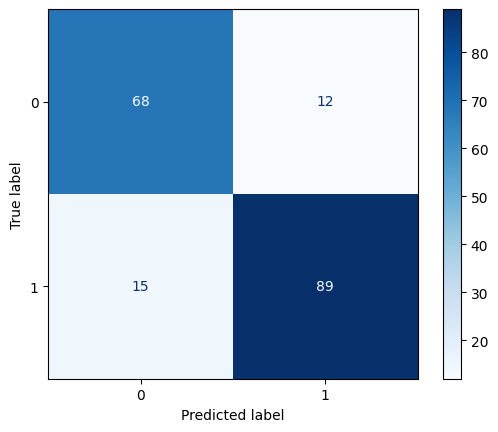

In [212]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    pipe4,
    x_test,
    y_test,
    cmap='Blues'
)

plt.show()

### 43.Calculating Accuracy Score
Imports accuracy_score to measure model performance.

Compares predicted values with actual test values.

Calculates and displays the model accuracy as a percentage.

In [213]:
from sklearn.metrics import accuracy_score
accuracy_score(pred, y_test)*100

85.32608695652173

### 44.Importing Ensemble and Classification Models
Imports VotingClassifier for combining multiple machine learning models.

#### Imports:
KNeighborsClassifier → K-Nearest Neighbors algorithm

SVC → Support Vector Machine classifier

LogisticRegression → Logistic Regression model

These models can be combined to build an ensemble learning model.

In [214]:
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

### 45.Creating a Voting Classifier Pipeline
#### Creates different machine learning models:
model2 → K-Nearest Neighbors with 5 neighbors

model3 → Support Vector Machine classifier

model4 → Logistic Regression model

Creates a VotingClassifier ensemble model.

Combines predictions from multiple classifiers.

voting='hard' selects the final prediction based on majority voting.

verbose=True displays training details for each model.

#### Builds a pipeline that:

Applies preprocessing using trans

Trains the Voting Classifier ensemble model

In [215]:
model2 = KNeighborsClassifier(5)
model3 = SVC()
model4 = LogisticRegression(solver= 'liblinear')
voting = VotingClassifier(estimators = [('x1',model2), ('x2',model3),('x3',model4)],voting = 'hard',verbose=True)
from sklearn.pipeline import make_pipeline
voting_pipe = make_pipeline(trans, voting)

### 46.Displaying the Voting Classifier Pipeline
Displays the complete machine learning pipeline.

Shows both the preprocessing steps and the Voting Classifier ensemble model combined together.

In [216]:
voting_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('votingclassifier',
                 VotingClassifier(estimators=[('x1', KNeighborsClassifier()),
                                              ('x2', SVC()),
                                              ('x3',
                                               LogisticRegression(solver='liblinear'))],
                                  verbose=True))])

### 47.Training the Voting Classifier Pipeline
Trains the Voting Classifier pipeline using the training dataset.

Applies preprocessing steps and fits all ensemble models to the data.

In [217]:
voting_pipe.fit(x_train, y_train)

[Voting] ....................... (1 of 3) Processing x1, total=   0.0s
[Voting] ....................... (2 of 3) Processing x2, total=   0.0s
[Voting] ....................... (3 of 3) Processing x3, total=   0.0s


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('votingclassifier',
                 VotingClassifier(estimators=[('x1', KNeighborsClassifier()),
                                              ('x2', SVC()),
                                              ('x3',
                                               LogisticRegression(solver='liblinear'))],
                                  verbose=True))])

### 48.Making Predictions with Voting Classifier
Uses the trained Voting Classifier pipeline to predict values for the test dataset.

Combines predictions from multiple models to generate final predictions.

Displays the predicted output values.

In [218]:
voting_prediction = voting_pipe.predict(x_test)
voting_prediction

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0], dtype=int64)

### 49.Calculating Voting Classifier Accuracy
Compares the predicted values with the actual test values.

Calculates the accuracy percentage of the Voting Classifier model.

Helps evaluate the overall performance of the ensemble model.

In [219]:
accuracy_score(voting_prediction, y_test)*100

86.95652173913044

### 50.Creating a Bagging Classifier
Imports BaggingClassifier for ensemble learning.

Imports SVC as the base classification model.

Creates an SVM model (model15).

Creates a Bagging Classifier (model16) using SVM as the base estimator.

n_estimators=10 means 10 SVM models are trained.

random_state=42 ensures reproducible results.

Bagging improves model stability and reduces overfitting.

In [220]:
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC

model15 = SVC()

model16 = BaggingClassifier(
    estimator=SVC(),
    n_estimators=10,
    random_state=42
)

### 51.Creating Bagging Classifier Pipeline
Imports make_pipeline to combine preprocessing and model training.

#### Builds a pipeline that:
Applies preprocessing using trans

Trains the Bagging Classifier model

Displays the complete pipeline structure.

In [221]:
from sklearn.pipeline import make_pipeline
pipe5 = make_pipeline(trans, model16)
pipe5

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('baggingclassifier',
                 BaggingClassifier(estimator=SVC(), random_state=42))])

### 52.Training the Bagging Classifier Pipeline
Trains the Bagging Classifier pipeline using the training dataset.

Applies preprocessing steps and fits the ensemble model to the data.

In [222]:
pipe5.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('baggingclassifier',
                 BaggingClassifier(estimator=SVC(), random_state=42))])

### 53.Making Predictions with Bagging Classifier
Uses the trained Bagging Classifier pipeline to predict values for the test dataset.

Generates predictions using the ensemble learning model.

Displays the predicted output values.

In [223]:
prediction5 = pipe5.predict(x_test)
prediction5

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0], dtype=int64)

### 54.Calculating Bagging Classifier Accuracy
Compares the predicted values with the actual test values.

Calculates the accuracy percentage of the Bagging Classifier model.

Helps evaluate the performance of the ensemble learning model.

In [224]:
accuracy_score(prediction5, y_test)*100

85.32608695652173

### 55.Creating Decision Tree Pipeline
Imports the DecisionTreeClassifier algorithm for classification tasks.

Creates a Decision Tree classification model.

#### Builds a pipeline that:
Applies preprocessing using trans

Trains the Decision Tree model

Displays the complete pipeline structure.

In [225]:
from sklearn.tree import DecisionTreeClassifier
model17 = DecisionTreeClassifier()
pipe6 = make_pipeline(trans,model17)
pipe6

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('decisiontreeclassifier', DecisionTreeClassifier())])

### 56.Training the Decision Tree Model
Trains the Decision Tree pipeline using the training dataset.

Applies preprocessing steps and fits the Decision Tree model to the data.

In [226]:
pipe6.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('decisiontreeclassifier', DecisionTreeClassifier())])

### 57.Making Predictions with Decision Tree Model
Uses the trained Decision Tree pipeline to predict values for the test dataset.

Stores and displays the predicted output values.

In [227]:
prediction6 = pipe6.predict(x_test)
prediction6

array([0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0], dtype=int64)

### 58.Calculating Decision Tree Model Accuracy
Compares the predicted values with the actual test values.

Calculates the accuracy percentage of the Decision Tree model.

Helps evaluate the model’s prediction performance.

In [228]:
accuracy_score(prediction6,y_test)*100

83.69565217391305

### 59.Creating Random Forest Pipeline
Imports the RandomForestClassifier ensemble learning algorithm.

Creates a Random Forest classification model with 300 decision trees.

#### Builds a pipeline that:
Applies preprocessing using trans

Trains the Random Forest model

Displays the complete pipeline structure.

In [229]:
from sklearn.ensemble import RandomForestClassifier
model18 = RandomForestClassifier(n_estimators=300)
pipe7 = make_pipeline(trans, model18)
pipe7

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=300))])

### 60.Training the Random Forest Model
Trains the Random Forest pipeline using the training dataset.

Applies preprocessing steps and fits the Random Forest model to the data.

In [230]:
pipe7.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=300))])

### 61.Making Predictions with Random Forest Model
Uses the trained Random Forest pipeline to predict values for the test dataset.

Stores and displays the predicted output values.

In [231]:
prediction7 = pipe7.predict(x_test)
prediction7

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0], dtype=int64)

### 62.Calculating Random Forest Model Accuracy
Compares the predicted values with the actual test values.

Calculates the accuracy percentage of the Random Forest model.

Helps evaluate the model’s prediction performance.

In [232]:
accuracy_score(prediction7,y_test)*100

86.95652173913044

### 63.Creating Another Decision Tree Pipeline
Imports the DecisionTreeClassifier algorithm.

Imports make_pipeline to combine preprocessing and model training.

Creates a Decision Tree classification model.

#### Builds a pipeline that:
Applies preprocessing using trans

Trains the Decision Tree model

Stores the complete pipeline in pipe8.

In [233]:
from sklearn.tree import DecisionTreeClassifier
model19 = DecisionTreeClassifier()
from sklearn.pipeline import make_pipeline
pipe8 = make_pipeline(trans,model19)

### 64.Creating Grid Search Pipeline for Hyperparameter Tuning
Imports GridSearchCV for hyperparameter tuning.

Imports the DecisionTreeClassifier model.

Defines different hyperparameter values for tuning the Decision Tree model.

#### Parameters include:
criterion → Splitting method

max_depth → Maximum depth of the tree

min_samples_split → Minimum samples required to split a node

min_samples_leaf → Minimum samples required in a leaf node

Creates a pipeline with preprocessing and Grid Search optimization.

cv=3 performs 3-fold cross-validation.

n_jobs=-1 uses all CPU cores for faster execution.

verbose=3 displays detailed training progress.

Helps find the best hyperparameters for the Decision Tree model.

In [234]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
params = {'criterion':['gini','entropy'],
         'max_depth':[None,2,6,7,12],
         'min_samples_split':[2,4,7,10],
         'min_samples_leaf':[15,100]}
pipe9 = make_pipeline(trans,GridSearchCV(model19,params,cv=3,n_jobs=-1,verbose=3))
pipe9

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('gridsearchcv',
                 GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                              n_jobs=-1,
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [None, 2, 6, 7, 12],
                                          'min_samples_leaf': [15, 100],
                                          'min_samples_split': [2, 4, 7, 10]},
                              verbose=3))])

### 65.Training the Grid Search Pipeline
Trains the pipeline using the training dataset.

Applies preprocessing steps and performs hyperparameter tuning using Grid Search.

Finds the best Decision Tree model based on cross-validation performance.

In [235]:
pipe9.fit(x_train,y_train)

Fitting 3 folds for each of 80 candidates, totalling 240 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('gridsearchcv',
                 GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                              n_jobs=-1,
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [None, 2, 6, 7, 12],
                                          'min_samples_leaf': [15, 100],
                                          'min_samples_split': [2, 4, 7, 10]},
                              verbose=3))])

### 66.Making Predictions with Tuned Decision Tree Model
Uses the trained Grid Search pipeline to predict values for the test dataset.

Generates predictions using the best optimized Decision Tree model.

Displays the predicted output values.

In [236]:
prediction8 = pipe9.predict(x_test)
prediction8

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0], dtype=int64)

### 67.Calculating Tuned Decision Tree Model Accuracy
Compares the predicted values with the actual test values.

Calculates the accuracy percentage of the tuned Decision Tree model.

Helps evaluate the performance of the optimized model.

In [237]:
accuracy_score(prediction8, y_test)*100

84.78260869565217

### 68.Displaying Pipeline Steps
Displays all steps present in the pipeline.

Shows the names and sequence of preprocessing and model components used in pipe9.

In [238]:
pipe9.named_steps

{'columntransformer': ColumnTransformer(remainder='passthrough',
                   transformers=[('onehotencoder',
                                  OneHotEncoder(sparse_output=False),
                                  [2, 6, 10]),
                                 ('ordinalencoder', OrdinalEncoder(), [1, 8]),
                                 ('standardscaler', StandardScaler(),
                                  [0, 3, 4, 5, 7, 9])]),
 'gridsearchcv': GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
              param_grid={'criterion': ['gini', 'entropy'],
                          'max_depth': [None, 2, 6, 7, 12],
                          'min_samples_leaf': [15, 100],
                          'min_samples_split': [2, 4, 7, 10]},
              verbose=3)}

### 69.Displaying Best Hyperparameters
Retrieves the best hyperparameter values found by GridSearchCV.

Displays the optimal parameters for the Decision Tree model based on cross-validation performance.

In [239]:
pipe9.named_steps['gridsearchcv'].best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 15,
 'min_samples_split': 2}

### 70.Creating Another Decision Tree Pipeline
Imports the DecisionTreeClassifier algorithm.

Imports make_pipeline to combine preprocessing and model training.

Creates a new Decision Tree classification model.

#### Builds a pipeline that:
Applies preprocessing using trans

Trains the Decision Tree model

Stores the pipeline in pipe10.

In [240]:
from sklearn.tree import DecisionTreeClassifier
model20 = DecisionTreeClassifier()
from sklearn.pipeline import make_pipeline
pipe10 = make_pipeline(trans,model20)

### 71.Creating Optimized Decision Tree Grid Search Pipeline
Imports GridSearchCV for hyperparameter tuning.

Imports the DecisionTreeClassifier model.

Defines hyperparameter values for tuning the Decision Tree model.

Tests different splitting criteria while keeping other parameters fixed.

Creates a pipeline with preprocessing and Grid Search optimization.

Performs 3-fold cross-validation to find the best model settings.

Uses all CPU cores for faster execution with n_jobs=-1.

Displays the complete optimized pipeline structure.

In [241]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
params = {'criterion':['gini','entropy'],
         'max_depth':[None],
         'min_samples_split':[2],
         'min_samples_leaf':[15]}
pipe10 = make_pipeline(trans,GridSearchCV(model20,params,cv=3,n_jobs=-1,verbose=3))
pipe10

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('gridsearchcv',
                 GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                              n_jobs=-1,
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [None],
                                          'min_samples_leaf': [15],
                                          'min_samples_split': [2]},
                              verbose=3))])

### 72.Training the Optimized Grid Search Pipeline
Trains the pipeline using the training dataset.

Applies preprocessing and performs Grid Search hyperparameter tuning.

Finds the best Decision Tree model based on cross-validation results.

In [242]:
pipe10.fit(x_train,y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('gridsearchcv',
                 GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                              n_jobs=-1,
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [None],
                                          'min_samples_leaf': [15],
                                          'min_samples_split': [2]},
                              verbose=3))])

### 73.Making Predictions with Optimized Decision Tree Model
Uses the trained Grid Search pipeline to predict values for the test dataset.

Generates predictions using the optimized Decision Tree model.

Stores the predicted output values in prediction11.

In [243]:
prediction11 = pipe10.predict(x_test)

### 74.Calculating Optimized Decision Tree Model Accuracy
Compares the predicted values with the actual test values.

Calculates the accuracy percentage of the optimized Decision Tree model.

Helps evaluate the performance of the tuned model.

In [244]:
accuracy_score(prediction11,y_test)*100

84.78260869565217

### 75.Creating Decision Tree Pipeline
Imports the DecisionTreeClassifier algorithm.

Imports make_pipeline to combine preprocessing and model training

Creates a Decision Tree classification model.

#### Builds a pipeline that:
Applies preprocessing using trans

Trains the Decision Tree model

Stores the complete pipeline in pipe11.

In [245]:
from sklearn.tree import DecisionTreeClassifier
model21 = DecisionTreeClassifier()
from sklearn.pipeline import make_pipeline
pipe11 = make_pipeline(trans,model21)

### 76.Creating Randomized Search Pipeline for Decision Tree
Imports RandomizedSearchCV for random hyperparameter tuning.

Imports the DecisionTreeClassifier model.

Defines a range of hyperparameters for tuning the Decision Tree model.

#### Includes different values for:
criterion

max_depth

min_samples_split

min_samples_leaf

Creates a pipeline with preprocessing and Randomized Search optimization.

Performs random hyperparameter tuning using cross-validation.

cv=3 applies 3-fold cross-validation.

n_jobs=-1 uses all CPU cores for faster execution.

verbose=3 shows detailed training progress.

In [246]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
params1 = {'criterion':['gini','entropy'],
         'max_depth':[None,2,10,15,20,25,3,5,7,12],
         'min_samples_split':[2,12,16,19,20,5,10,11,13,15,17],
         'min_samples_leaf':[15,20,25,30,35,36,38,40]}
pipe11 = make_pipeline(trans,RandomizedSearchCV(model21,params1,cv=3,n_jobs=-1,verbose=3))
pipe11

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('randomizedsearchcv',
                 RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                                    n_jobs=-1,
                                    param_distributions={'criterion': ['gini',
                                                                       'entropy'],
                                                         'max_depth': [None, 2,
                                                                       10, 15,
                                                                       20, 25,
                                                                       3, 5, 7,
                                                                       12],
                                                         'min_samples_leaf': [15,
                                                                              20,
                                                                              25,
                                                                              30,
                                                                              35,
                                                                              36,
                                                                              38,
                                                                              40],
                                                         'min_samples_split': [2,
                                                                               12,
                                                                               16,
                                                                               19,
                                                                               20,
                                                                               5,
                                                                               10,
                                                                               11,
                                                                               13,
                                                                               15,
                                                                               17]},
                                    verbose=3))])

### 77.Training the Randomized Search Pipeline
Trains the pipeline using the training dataset.

Applies preprocessing and performs random hyperparameter tuning.

Finds the best Decision Tree model based on cross-validation performance.

In [247]:
pipe11.fit(x_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('randomizedsearchcv',
                 RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                                    n_jobs=-1,
                                    param_distributions={'criterion': ['gini',
                                                                       'entropy'],
                                                         'max_depth': [None, 2,
                                                                       10, 15,
                                                                       20, 25,
                                                                       3, 5, 7,
                                                                       12],
                                                         'min_samples_leaf': [15,
                                                                              20,
                                                                              25,
                                                                              30,
                                                                              35,
                                                                              36,
                                                                              38,
                                                                              40],
                                                         'min_samples_split': [2,
                                                                               12,
                                                                               16,
                                                                               19,
                                                                               20,
                                                                               5,
                                                                               10,
                                                                               11,
                                                                               13,
                                                                               15,
                                                                               17]},
                                    verbose=3))])

### 78.Making Predictions with Randomized Search Model
Uses the trained Randomized Search pipeline to predict values for the test dataset.

Generates predictions using the optimized Decision Tree model.

Displays the predicted output values.

In [248]:
prediction12= pipe11.predict(x_test)
prediction12

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1], dtype=int64)

### 79.Calculating Randomized Search Model Accuracy
Compares the predicted values with the actual test values.

Calculates the accuracy percentage of the optimized Decision Tree model.

Helps evaluate the performance of the Randomized Search model.

In [249]:
accuracy_score(prediction12,y_test)*100

83.69565217391305

### 80.Displaying Best Parameters from Randomized Search
Retrieves the best hyperparameter values found by RandomizedSearchCV.

Displays the optimal Decision Tree parameters based on cross-validation results.

In [250]:
pipe11.named_steps['randomizedsearchcv'].best_params_

{'min_samples_split': 10,
 'min_samples_leaf': 20,
 'max_depth': 5,
 'criterion': 'entropy'}

### 81.Creating Decision Tree Pipeline
Imports the DecisionTreeClassifier algorithm.

Imports make_pipeline to combine preprocessing and model training

Creates a Decision Tree classification model.

#### Builds a pipeline that:
Applies preprocessing using trans

Trains the Decision Tree model

Stores the complete pipeline in pipe12.

In [251]:
from sklearn.tree import DecisionTreeClassifier
model22 = DecisionTreeClassifier()
from sklearn.pipeline import make_pipeline
pipe12 = make_pipeline(trans,model22)

### 82.Creating Optimized Randomized Search Pipeline
Imports RandomizedSearchCV for hyperparameter optimization.

Imports the DecisionTreeClassifier model.

Defines fixed hyperparameter values for the Decision Tree model.
#### Uses:
criterion='entropy'

max_depth=5

min_samples_split=20

min_samples_leaf=30

Creates a pipeline with preprocessing and Randomized Search optimization.

Applies 3-fold cross-validation to evaluate the model.

Uses all CPU cores for faster execution with n_jobs=-1.

Displays the complete optimized pipeline structure.

In [252]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
params1 = {'criterion':['entropy'],
         'max_depth':[5],
         'min_samples_split':[20],
         'min_samples_leaf':[30]}
pipe12 = make_pipeline(trans,RandomizedSearchCV(model22,params1,cv=3,n_jobs=-1,verbose=3))
pipe12

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('randomizedsearchcv',
                 RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                                    n_jobs=-1,
                                    param_distributions={'criterion': ['entropy'],
                                                         'max_depth': [5],
                                                         'min_samples_leaf': [30],
                                                         'min_samples_split': [20]},
                                    verbose=3))])

### 83.Training the Optimized Randomized Search Pipeline
Trains the pipeline using the training dataset.

Applies preprocessing and performs Randomized Search optimization.

In [253]:
pipe12.fit(x_train,y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\gowth\ANACONDA\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  [2, 6, 10]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), [1, 8]),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  [0, 3, 4, 5, 7, 9])])),
                ('randomizedsearchcv',
                 RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(),
                                    n_jobs=-1,
                                    param_distributions={'criterion': ['entropy'],
                                                         'max_depth': [5],
                                                         'min_samples_leaf': [30],
                                                         'min_samples_split': [20]},
                                    verbose=3))])

### 84.Making Predictions with Optimized Randomized Search Model
Uses the trained Randomized Search pipeline to predict values for the test dataset.

Generates predictions using the optimized Decision Tree model.

Displays the predicted output values.

In [254]:
prediction13= pipe12.predict(x_test)
prediction13

array([0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1], dtype=int64)

### 85.Calculating Optimized Randomized Search Model Accuracy
Compares the predicted values with the actual test values.

Calculates the accuracy percentage of the optimized Decision Tree model.

Helps evaluate the model’s prediction performance.

In [255]:
accuracy_score(prediction13,y_test)*100

80.97826086956522